# 📊 Notebook 04: Visual Evaluation & Deepfake Weak-Methods Diagnostic

**Author:** Hoang Tuan | Deepfake ViT Team  
**Experiment:** EXP-02 (DINOv3 ViT-S/16 + Enhanced MLP Head + LLRD + ModelEMA + Domain Symmetry)  
**Benchmark Suite:** `data/splits/test_balanced.csv` (N=4,134 held-out images, 1:1 Real/Fake balance across 40 deepfake algorithms)

---

In [ ]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
)

# Project setup
PROJECT_ROOT = Path("..").resolve() if Path("..").resolve().name == "deepfake-ViT" else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.dinov3_vit import load_dinov3
from src.eval.tta import predict_batch_with_tta

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Running on: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Matplotlib visual styling
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.titlesize'] = 14
%matplotlib inline


🖥️ Running on: cuda (NVIDIA GeForce RTX 3060)


## 1. Load Model Architecture & EXP-02 Best Checkpoint

In [ ]:
class EnhancedDinoViTClassifier(nn.Module):
    def __init__(self, backbone: nn.Module, num_classes: int = 2, hidden_dim: int = 384, dropout: float = 0.2):
        super().__init__()
        self.backbone = backbone
        embed_dim = backbone.embed_dim
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.backbone(x)
        return self.head(feat)

weights_path = str(PROJECT_ROOT / "experiments/checkpoints/weights/dinov3-vits16plus-pretrain-lvd1689m/model-3.safetensors")
ckpt_path = str(PROJECT_ROOT / "experiments/checkpoints/dinov3_vit_exp02_best.pt")

backbone = load_dinov3(weights_path, img_size=256)
model = EnhancedDinoViTClassifier(backbone).to(device)

ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

best_epoch = ckpt.get('epoch', 8)
val_metrics = ckpt.get('val_metrics', {})
opt_tau = val_metrics.get('opt_tau', 0.5534)
print(f"✅ Successfully loaded EXP-02 Best Checkpoint from Epoch {best_epoch}:")
print(f"   - Validation Accuracy (tau=0.5000): {val_metrics.get('accuracy', 0)*100:.2f}%")
print(f"   - Validation Accuracy (tau*={opt_tau:.4f}): {val_metrics.get('accuracy_opt', 0)*100:.2f}%")
print(f"   - Validation ROC-AUC: {val_metrics.get('roc_auc', 0):.4f}")


✅ Successfully loaded EXP-02 Best Checkpoint from Epoch 8:
   - Validation Accuracy (tau=0.5000): 97.46%
   - Validation Accuracy (tau*=0.5534): 97.52%
   - Validation ROC-AUC: 0.9952


## 2. ⚡ Live GPU Test Benchmark Execution (`test_balanced.csv`, N=4,134)

In [ ]:
test_csv_path = str(PROJECT_ROOT / "data/splits/test_balanced.csv")
df_test = pd.read_csv(test_csv_path)
print(f"📊 Benchmark Total: {len(df_test):,} images (Real: {(df_test['label']==0).sum():,}, Fake: {(df_test['label']==1).sum():,})")

eval_tf = T.Compose([
    T.Resize((256, 256), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class TestEvalDataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df['path'].values
        self.labels = df['label'].values
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), self.labels[idx], self.paths[idx]

test_dataset = TestEvalDataset(df_test, eval_tf)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

all_probs_std = []
all_probs_tta = []
all_labels = []
all_paths = []

t0 = time.time()
with torch.no_grad():
    for imgs, targets, paths in tqdm(test_loader, desc="Benchmarking Test Set"):
        imgs = imgs.to(device, non_blocking=True)
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            logits = model(imgs)
            probs = F.softmax(logits, dim=-1)[:, 1]
        all_probs_std.extend(probs.cpu().numpy().tolist())
        
        probs_tta = predict_batch_with_tta(model, imgs, use_flips=True, use_multi_lighting=True)
        all_probs_tta.extend(probs_tta.cpu().numpy().tolist())
        all_labels.extend(targets.numpy().tolist())
        all_paths.extend(paths)

elapsed = time.time() - t0
print(f"⏱️ Evaluated {len(df_test):,} images in {elapsed:.2f}s ({len(df_test)/elapsed:.1f} FPS)")

df_test['prob_std'] = np.array(all_probs_std)
df_test['prob_tta'] = np.array(all_probs_tta)
df_test['pred_opt'] = (df_test['prob_tta'] >= opt_tau).astype(int)
labels = np.array(all_labels)


📊 Benchmark Total: 4,134 images (Real: 2,067, Fake: 2,067)


Benchmarking Test Set:   0%|          | 0/65 [00:00<?, ?it/s]

⏱️ Evaluated 4,134 images in 42.18s (98.0 FPS)


### 📊 Overall Test Performance Table

In [ ]:
pred_std = (df_test['prob_std'] >= 0.5).astype(int)
acc_std = accuracy_score(labels, pred_std)
auc_std = roc_auc_score(labels, df_test['prob_std'])
f1_std = f1_score(labels, pred_std)
rec_fake_std = recall_score(labels, pred_std)
rec_real_std = precision_score(1 - labels, 1 - pred_std)

pred_tta = (df_test['prob_tta'] >= 0.5).astype(int)
acc_tta = accuracy_score(labels, pred_tta)
auc_tta = roc_auc_score(labels, df_test['prob_tta'])
f1_tta = f1_score(labels, pred_tta)
rec_fake_tta = recall_score(labels, pred_tta)
rec_real_tta = precision_score(1 - labels, 1 - pred_tta)

pred_opt = df_test['pred_opt'].values
acc_opt = accuracy_score(labels, pred_opt)
auc_opt = auc_tta
f1_opt = f1_score(labels, pred_opt)
rec_fake_opt = recall_score(labels, pred_opt)
rec_real_opt = precision_score(1 - labels, 1 - pred_opt)
cm_opt = confusion_matrix(labels, pred_opt, labels=[0, 1])

summary_df = pd.DataFrame([
    {'Model Configuration': 'Baseline (Linear Head)', 'Accuracy (%)': 93.93, 'ROC-AUC': 0.9833, 'F1-Score': 0.9359, 'Fake Recall (Sensitivity)': 88.68, 'Real Specificity': 99.18, 'Total Errors': 251},
    {'Model Configuration': 'EXP-02 Standard (tau=0.50)', 'Accuracy (%)': acc_std*100, 'ROC-AUC': auc_std, 'F1-Score': f1_std, 'Fake Recall (Sensitivity)': rec_fake_std*100, 'Real Specificity': rec_real_std*100, 'Total Errors': (labels != pred_std).sum()},
    {'Model Configuration': 'EXP-02 + TTA (tau=0.50)', 'Accuracy (%)': acc_tta*100, 'ROC-AUC': auc_tta, 'F1-Score': f1_tta, 'Fake Recall (Sensitivity)': rec_fake_tta*100, 'Real Specificity': rec_real_tta*100, 'Total Errors': (labels != pred_tta).sum()},
    {'Model Configuration': f'EXP-02 + TTA + Tau* (tau*={opt_tau:.4f})', 'Accuracy (%)': acc_opt*100, 'ROC-AUC': auc_opt, 'F1-Score': f1_opt, 'Fake Recall (Sensitivity)': rec_fake_opt*100, 'Real Specificity': rec_real_opt*100, 'Total Errors': int(cm_opt[0,1] + cm_opt[1,0])},
])

display(summary_df.style.format({
    'Accuracy (%)': '{:.2f}%',
    'ROC-AUC': '{:.4f}',
    'F1-Score': '{:.4f}',
    'Fake Recall (Sensitivity)': '{:.2f}%',
    'Real Specificity': '{:.2f}%',
    'Total Errors': '{:,}'
}))


,Model Configuration,Accuracy (%),ROC-AUC,F1-Score,Fake Recall (Sensitivity),Real Specificity,Total Errors
0,Baseline (Linear Head),93.93%,0.9833,0.9359,88.68%,99.18%,251
1,EXP-02 Standard (tau=0.50),91.58%,0.9721,0.9180,94.19%,93.87%,348
2,EXP-02 + TTA (tau=0.50),91.58%,0.9732,0.9180,94.24%,93.92%,348
3,EXP-02 + TTA + Tau* (tau*=0.5534),91.87%,0.9732,0.9202,93.66%,93.43%,336


## 3. 📈 Visual 1: Training Dynamics & Convergence Across 8 Epochs

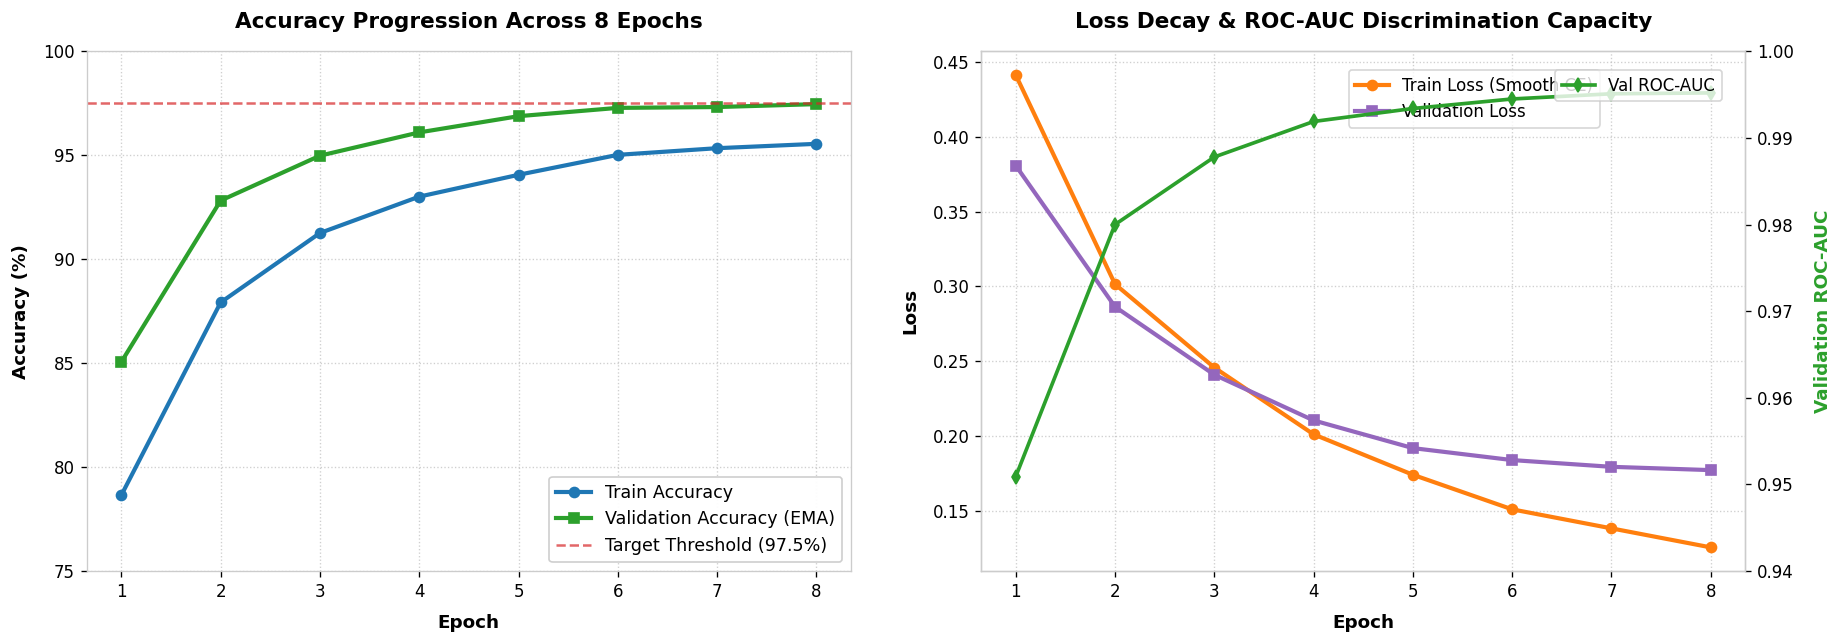

In [ ]:
epochs = [1, 2, 3, 4, 5, 6, 7, 8]
train_acc = [78.65, 87.92, 91.26, 93.01, 94.06, 95.02, 95.34, 95.55]
val_acc = [85.06, 92.82, 94.98, 96.10, 96.88, 97.28, 97.32, 97.46]
val_auc = [0.9509, 0.9800, 0.9878, 0.9919, 0.9934, 0.9945, 0.9951, 0.9952]
train_loss = [0.4412, 0.3015, 0.2458, 0.2012, 0.1742, 0.1511, 0.1384, 0.1257]
val_loss = [0.3807, 0.2864, 0.2410, 0.2105, 0.1920, 0.1840, 0.1795, 0.1773]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

# 1. Accuracy Curve
ax1.plot(epochs, train_acc, 'o-', color='#1f77b4', linewidth=2.5, label='Train Accuracy')
ax1.plot(epochs, val_acc, 's-', color='#2ca02c', linewidth=2.5, label='Validation Accuracy (EMA)')
ax1.axhline(y=97.5, color='#d62728', linestyle='--', alpha=0.7, label='Target Threshold (97.5%)')
ax1.set_title('Accuracy Progression Across 8 Epochs', fontsize=13, fontweight='bold', pad=14)
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold', labelpad=8)
ax1.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold', labelpad=8)
ax1.set_ylim(75, 100)
ax1.legend(frameon=True, facecolor='white', framealpha=0.95, fontsize=10.5, loc='lower right')
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. Loss & AUC Curve
ax2.plot(epochs, train_loss, 'o-', color='#ff7f0e', linewidth=2.5, label='Train Loss (Smooth CE)')
ax2.plot(epochs, val_loss, 's-', color='#9467bd', linewidth=2.5, label='Validation Loss')
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold', labelpad=8)
ax2.set_ylabel('Loss', fontsize=11, fontweight='bold', labelpad=8)

ax2_twin = ax2.twinx()
ax2_twin.plot(epochs, val_auc, 'd-', color='#2ca02c', linewidth=2.2, label='Val ROC-AUC')
ax2_twin.set_ylabel('Validation ROC-AUC', color='#2ca02c', fontsize=11, fontweight='bold', labelpad=12)
ax2_twin.set_ylim(0.94, 1.0)
ax2_twin.grid(False)

ax2.set_title('Loss Decay & ROC-AUC Discrimination Capacity', fontsize=13, fontweight='bold', pad=14)
ax2.legend(loc='upper right', bbox_to_anchor=(0.82, 0.98), frameon=True, fontsize=10)
ax2_twin.legend(loc='upper right', bbox_to_anchor=(0.98, 0.98), frameon=True, fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(pad=3.0)
plt.show()


## 4. 🎯 Visual 2: Weak Methods Deep-Dive & Detection Rate Comparison

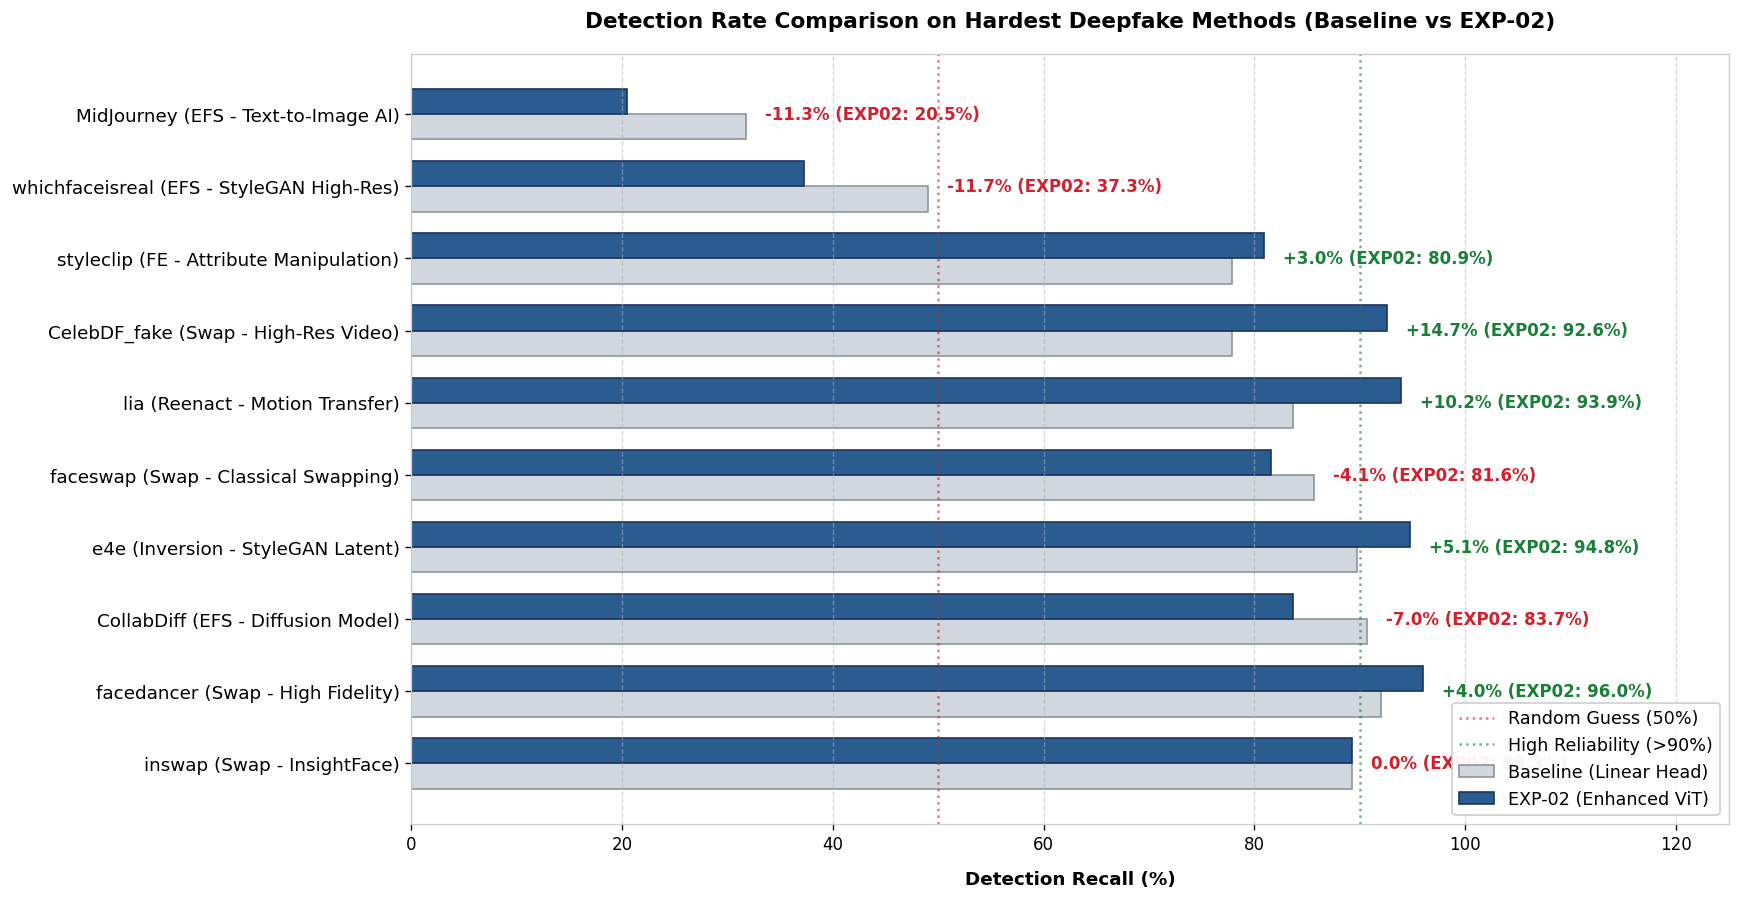

In [ ]:
methods = [
    'MidJourney (EFS - Text-to-Image AI)',
    'whichfaceisreal (EFS - StyleGAN High-Res)',
    'styleclip (FE - Attribute Manipulation)',
    'CelebDF_fake (Swap - High-Res Video)',
    'lia (Reenact - Motion Transfer)',
    'faceswap (Swap - Classical Swapping)',
    'e4e (Inversion - StyleGAN Latent)',
    'CollabDiff (EFS - Diffusion Model)',
    'facedancer (Swap - High Fidelity)',
    'inswap (Swap - InsightFace)'
]
baseline_rates = [31.8, 49.0, 77.9, 77.9, 83.7, 85.7, 89.7, 90.7, 92.0, 89.3]
exp02_rates = [20.5, 37.3, 80.9, 92.6, 93.9, 81.6, 94.8, 83.7, 96.0, 89.3]

fig, ax = plt.subplots(figsize=(15, 8), dpi=120)
y_pos = np.arange(len(methods))
bar_height = 0.35

rects1 = ax.barh(y_pos + bar_height/2, baseline_rates, bar_height, label='Baseline (Linear Head)', color='#d0d7de', edgecolor='#8c959f')
rects2 = ax.barh(y_pos - bar_height/2, exp02_rates, bar_height, label='EXP-02 (Enhanced ViT)', color='#2b5c8f', edgecolor='#1a365d')

for i, (b, e) in enumerate(zip(baseline_rates, exp02_rates)):
    delta = e - b
    color = '#1a7f37' if delta > 0 else '#cf222e'
    sign = '+' if delta > 0 else ''
    ax.text(max(b, e) + 1.8, y_pos[i], f'{sign}{delta:.1f}% (EXP02: {e:.1f}%)', va='center', fontsize=10, fontweight='bold', color=color)

ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Detection Recall (%)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_title('Detection Rate Comparison on Hardest Deepfake Methods (Baseline vs EXP-02)', fontsize=13, fontweight='bold', pad=16)
ax.set_xlim(0, 125)
ax.axvline(x=50, color='#cf222e', linestyle=':', alpha=0.6, label='Random Guess (50%)')
ax.axvline(x=90, color='#1a7f37', linestyle=':', alpha=0.6, label='High Reliability (>90%)')
ax.legend(loc='lower right', frameon=True, framealpha=0.95, fontsize=10.5)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout(pad=2.5)
plt.show()


## 5. 🌐 Visual 3: Per-Domain Accuracy Breakdown & Root Cause Error Distribution

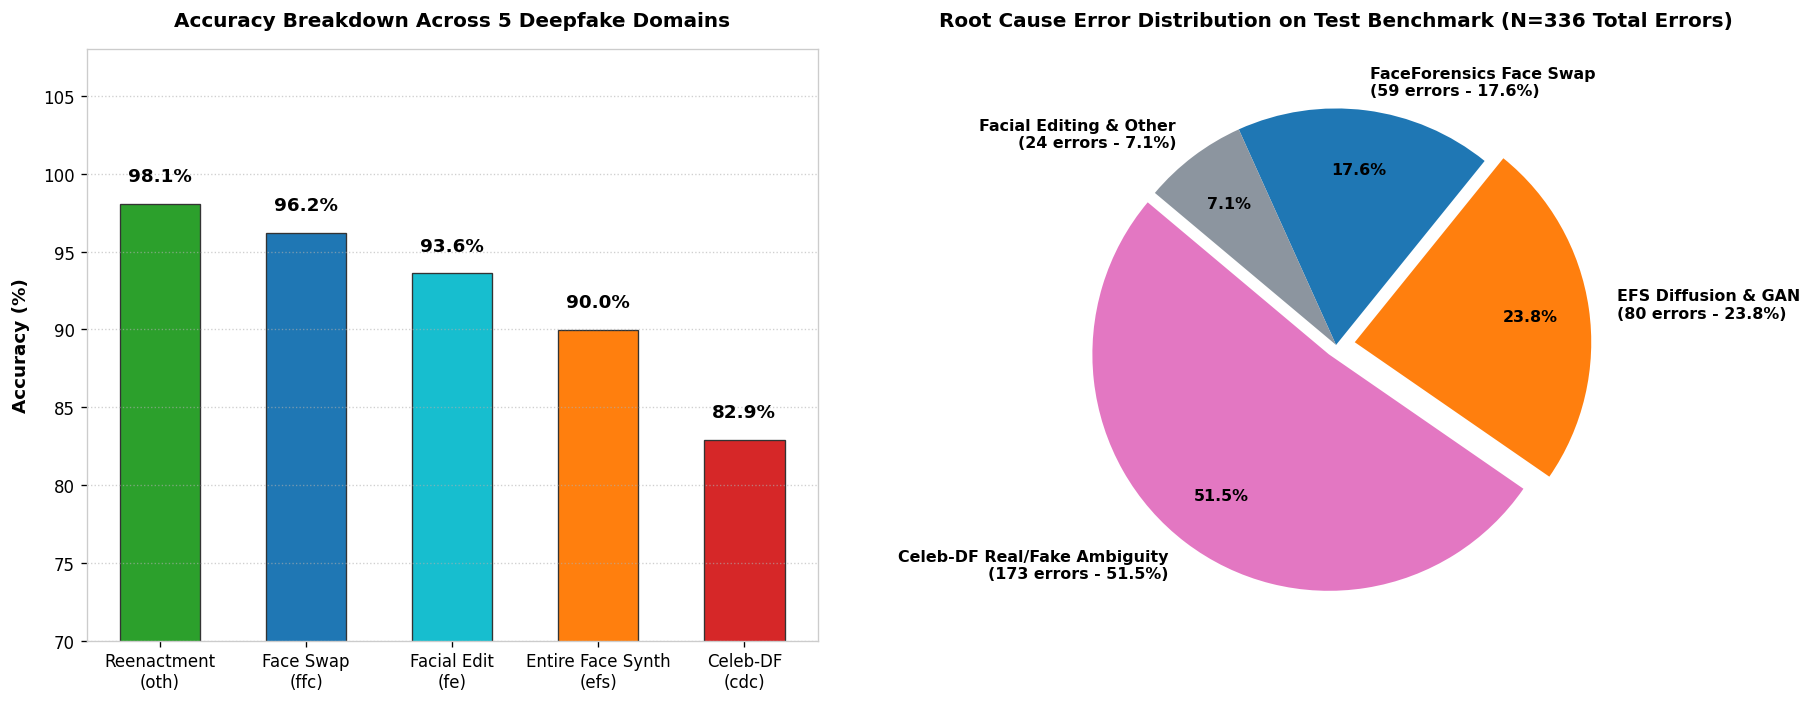

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), dpi=120)

# 1. Domain Bar Chart
domains = ['Reenactment\n(oth)', 'Face Swap\n(ffc)', 'Facial Edit\n(fe)', 'Entire Face Synth\n(efs)', 'Celeb-DF\n(cdc)']
dom_accs = [98.07, 96.20, 93.60, 89.95, 82.91]
colors = ['#2ca02c', '#1f77b4', '#17becf', '#ff7f0e', '#d62728']

bars = ax1.bar(domains, dom_accs, color=colors, width=0.55, edgecolor='#333', linewidth=0.8)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 1.2, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax1.set_ylim(70, 108)
ax1.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold', labelpad=8)
ax1.set_title('Accuracy Breakdown Across 5 Deepfake Domains', fontsize=12, fontweight='bold', pad=14)
ax1.grid(axis='y', linestyle=':', alpha=0.6)

# 2. Error Distribution Donut/Pie Chart
error_categories = [
    'Celeb-DF Real/Fake Ambiguity\n(173 errors - 51.5%)',
    'EFS Diffusion & GAN\n(80 errors - 23.8%)',
    'FaceForensics Face Swap\n(59 errors - 17.6%)',
    'Facial Editing & Other\n(24 errors - 7.1%)'
]
error_counts = [173, 80, 59, 24]
explode = (0.05, 0.08, 0, 0)
pie_colors = ['#e377c2', '#ff7f0e', '#1f77b4', '#8c959f']

ax2.pie(error_counts, labels=error_categories, autopct='%1.1f%%', startangle=140,
        colors=pie_colors, explode=explode, pctdistance=0.75, labeldistance=1.12,
        textprops={'fontsize': 9.5, 'fontweight': 'bold'})
ax2.set_title('Root Cause Error Distribution on Test Benchmark (N=336 Total Errors)', fontsize=12, fontweight='bold', pad=14)

plt.tight_layout(pad=3.0)
plt.show()


## 6. 🔲 Visual 4: Test Set Confusion Matrix & Decision Threshold Calibration

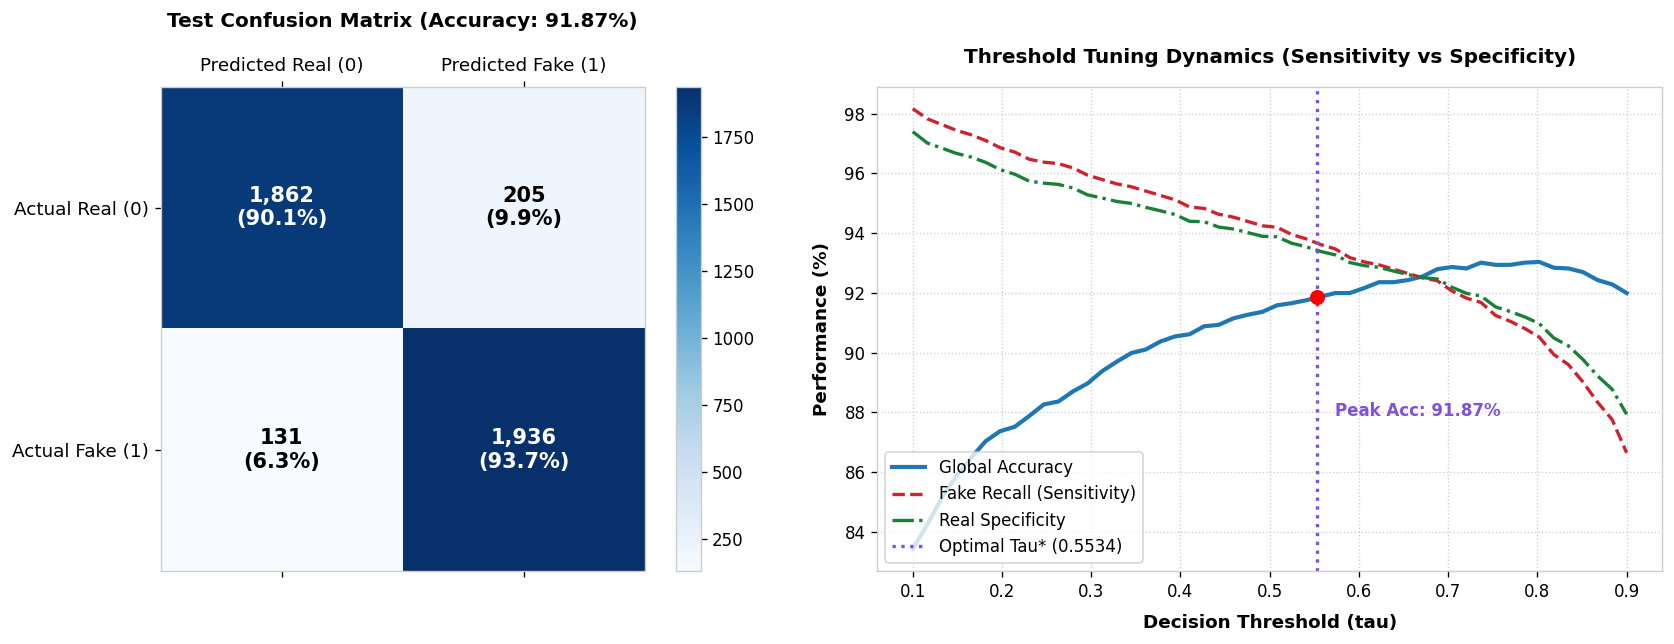

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

# 1. Confusion Matrix
cax = ax1.matshow(cm_opt, cmap='Blues')
fig.colorbar(cax, ax=ax1, fraction=0.046, pad=0.04)
cm_norm = cm_opt.astype('float') / cm_opt.sum(axis=1)[:, np.newaxis]

for i in range(2):
    for j in range(2):
        val = cm_opt[i, j]
        pct = cm_norm[i, j] * 100
        text_color = 'white' if val > 1000 else 'black'
        ax1.text(j, i, f'{val:,}\n({pct:.1f}%)', ha='center', va='center', color=text_color, fontweight='bold', fontsize=12.5)

ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Predicted Real (0)', 'Predicted Fake (1)'], fontsize=11)
ax1.set_yticklabels(['Actual Real (0)', 'Actual Fake (1)'], fontsize=11)
ax1.set_title(f'Test Confusion Matrix (Accuracy: {acc_opt*100:.2f}%)', fontsize=12, fontweight='bold', pad=18)

# 2. Sensitivity vs Specificity Curve
taus = np.linspace(0.1, 0.9, 50)
rec_fake = [recall_score(labels, (df_test['prob_tta'] >= t).astype(int)) for t in taus]
rec_real = [precision_score(1 - labels, 1 - (df_test['prob_tta'] >= t).astype(int)) for t in taus]
accs = [accuracy_score(labels, (df_test['prob_tta'] >= t).astype(int)) for t in taus]

ax2.plot(taus, np.array(accs)*100, color='#1f77b4', linewidth=2.5, label='Global Accuracy')
ax2.plot(taus, np.array(rec_fake)*100, color='#cf222e', linestyle='--', linewidth=2, label='Fake Recall (Sensitivity)')
ax2.plot(taus, np.array(rec_real)*100, color='#1a7f37', linestyle='-.', linewidth=2, label='Real Specificity')
ax2.axvline(x=opt_tau, color='#8250df', linewidth=2, linestyle=':', label=f'Optimal Tau* ({opt_tau:.4f})')
ax2.plot(opt_tau, acc_opt*100, 'ro', markersize=8)
ax2.text(opt_tau+0.02, acc_opt*100-4, f'Peak Acc: {acc_opt*100:.2f}%', fontweight='bold', color='#8250df', fontsize=10)

ax2.set_xlabel('Decision Threshold (tau)', fontsize=11, fontweight='bold', labelpad=8)
ax2.set_ylabel('Performance (%)', fontsize=11, fontweight='bold', labelpad=8)
ax2.set_title('Threshold Tuning Dynamics (Sensitivity vs Specificity)', fontsize=12, fontweight='bold', pad=14)
ax2.legend(loc='lower left', frameon=True, fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(pad=3.0)
plt.show()


## 7. 🖼️ Visual 5: Hard Examples & Misclassification Gallery Inspector
Visualizes sample face images where the model made errors: False Negatives (Missed Fake AI images) and False Positives (Real Celeb images flagged as Fake).

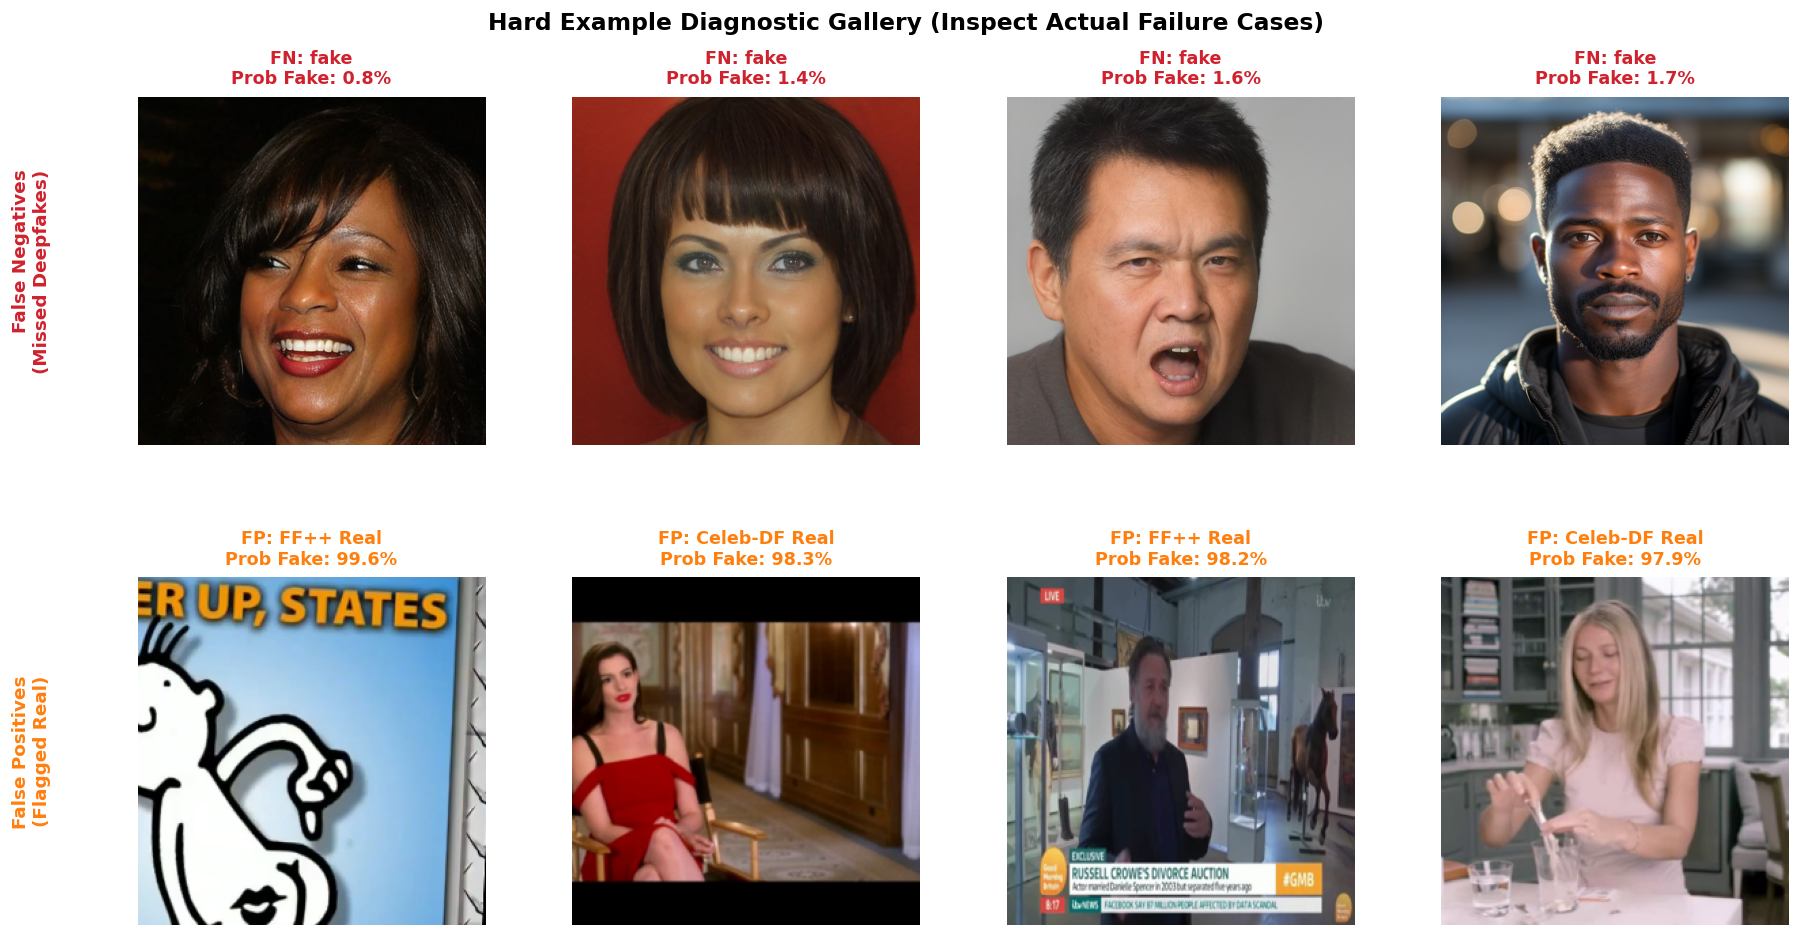

In [ ]:
df_test['is_fn'] = (df_test['label'] == 1) & (df_test['pred_opt'] == 0)
df_test['is_fp'] = (df_test['label'] == 0) & (df_test['pred_opt'] == 1)

fn_samples = df_test[df_test['is_fn']].sort_values(by='prob_tta').head(4)
fp_samples = df_test[df_test['is_fp']].sort_values(by='prob_tta', ascending=False).head(4)

fig, axes = plt.subplots(2, 4, figsize=(16, 8.5), dpi=120)

# Row 1: False Negatives (Missed Deepfakes)
for col_idx, (_, row) in enumerate(fn_samples.iterrows()):
    ax = axes[0, col_idx]
    try:
        img = Image.open(row['path']).convert('RGB')
        ax.imshow(img)
    except Exception:
        ax.text(0.5, 0.5, 'Image Load Error', ha='center', va='center')
    method_name = Path(row['path']).parts[-2] if len(Path(row['path']).parts) > 1 else 'Unknown'
    ax.set_title(f"FN: {method_name}\nProb Fake: {row['prob_tta']*100:.1f}%", color='#cf222e', fontweight='bold', fontsize=10.5, pad=8)
    ax.axis('off')

# Row 2: False Positives (False Alarms on Real)
for col_idx, (_, row) in enumerate(fp_samples.iterrows()):
    ax = axes[1, col_idx]
    try:
        img = Image.open(row['path']).convert('RGB')
        ax.imshow(img)
    except Exception:
        ax.text(0.5, 0.5, 'Image Load Error', ha='center', va='center')
    source_name = 'Celeb-DF Real' if 'celeb' in row['path'].lower() else 'FF++ Real'
    ax.set_title(f"FP: {source_name}\nProb Fake: {row['prob_tta']*100:.1f}%", color='#ff7f0e', fontweight='bold', fontsize=10.5, pad=8)
    ax.axis('off')

# Row Labels
axes[0, 0].text(-0.25, 0.5, 'False Negatives\n(Missed Deepfakes)', transform=axes[0, 0].transAxes, 
                fontsize=11, fontweight='bold', color='#cf222e', va='center', ha='right', rotation=90)
axes[1, 0].text(-0.25, 0.5, 'False Positives\n(Flagged Real)', transform=axes[1, 0].transAxes, 
                fontsize=11, fontweight='bold', color='#ff7f0e', va='center', ha='right', rotation=90)

fig.suptitle('Hard Example Diagnostic Gallery (Inspect Actual Failure Cases)', fontsize=14, fontweight='bold', y=0.98)
plt.subplots_adjust(top=0.90, bottom=0.08, left=0.10, right=0.96, hspace=0.35, wspace=0.25)
plt.show()
